<div style="display:flex;align-items:center;gap:16px;">
  <div style="font-size:52px;">📈</div>
  <div>
    <h1 style="margin-bottom:4px;">Tecnical Inform – Prediction <code>interest_rate</code></h1>
    <p style="margin-top:0;color:#666;">Generado 2025-09-08 01:48</p>
  </div>
</div>

<div style="margin-top:8px;padding:12px;border-left:5px solid #4F46E5;background:#F3F4F6;">
<b>Purpose:</b> Build, evaluate model comparison of regresion (PyCaret vs scikit-learn) to estimate interest rate.
</div>



## 🧭 Content

1. 🗂️ [Data & configuration](#data-config)
2. 🔍 [Quick EDA](#eda)
3. 🤖 [Modeling with PyCaret](#pycaret)
4. 🧪 [Metrics & Visuals (PyCaret)](#metrics-pycaret)
5. 🛠️ [Modelling with scikit-learn (RandomForest/LightGBM)](#sklearn)
6. ⚖️ [Metrics comparative](#comparative)
7. 🖼️ [Presentation Graphics](#graphics)
8. 📝 [Recomendations and Conclusions](#conclutions)
9. 📎 [Exportables](#exportables)



<a id="data-config"></a>

## 🗂️ Data & Problem Definition

> 1. Introduction

The objective of this project is to develop a predictive model capable of estimating the interest rate assigned to financial clients based on their profile and product characteristics.

Two datasets were used:

df_train: historical observations including the target variable (tasa_interes)
df_test: new observations without the target, used to generate predictions

The primary evaluation metric is RMSE, supported by MAE and R², ensuring both accuracy and interpretability of the model.

## 💼Business Context

In financial institutions, interest rate assignment is directly linked to risk assessment and profitability. Accurately estimating interest rates allows:

Better alignment between customer risk profile and pricing strategy
Improved portfolio performance
More consistent and data-driven decision-making

## 🎯 Objective

The goal is not only to minimize prediction error, but to build a model that can support personalized and scalable interest rate assignment, enhancing both risk management and customer segmentation strategies.

In [6]:

# Librerías base
import os, math, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt

# Rutas
PATH_TRAIN = "df_train.csv"
PATH_TEST  = "df_test.csv"

# Carga de datos
df_train = pd.read_csv(PATH_TRAIN)
df_test  = pd.read_csv(PATH_TEST)

print("df_train:", df_train.shape, " | df_test:", df_test.shape)
assert 'tasa_interes' in df_train.columns, "El target 'tasa_interes' no está en df_train."
assert 'id' in df_test.columns, "df_test debe contener la columna 'id'."


df_train: (13923, 18)  | df_test: (5967, 17)



<a id="2.eda"></a>

## ⚙️ Modeling Approach

The modeling process was designed to ensure both efficiency in experimentation and robustness in results, combining automated and manual approaches.

## 🔍 Data Exploration

An initial exploratory analysis was conducted to validate data quality, identify inconsistencies, and detect potential outliers. This step ensured that the dataset was reliable for modeling and aligned with expected financial behavior patterns.

,id,categoria,edad,genero,estado_civil,ingreso_reportado,maximo_dias_mora,saldo_total,saldo_productos_activos,saldo_productos_pasivos,cantidad_productos_activos,cantidad_productos_pasivos,saldo_en_competencia,monto_credito,plazo_credito,calificacion_crediticia,garantia_credito,tasa_interes
0,665928,optima,47.0,femenino,divorciado,130730.0,17.0,447609.0,421694.0,25915.0,2.0,3.0,217496.53,616000.0,248.0,4.0,hipotecaria,6.62
1,845135,privada,58.0,masculino,casado,NaN,19.0,2462266.0,497449.0,1964817.0,1.0,3.0,480842.73,219000.0,98.0,2.0,autoliquidable,7.81
2,221108,optima,47.0,femenino,casado,113685.0,9.0,74209.0,66339.0,7870.0,3.0,2.0,197102.08,210000.0,50.0,3.0,fiduciaria,13.46


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,13923.0,NaN,NaN,NaN,549389.089277,259578.821304,100041.0,324490.5,546603.0,772821.0,999963.0
categoria,13923,3,optima,9399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,13923.0,NaN,NaN,NaN,343684624977.007263,40511348172690.210938,16.0,37.0,43.0,51.0,4780165219229881.0
genero,13923,2,femenino,7079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado_civil,13923,4,casado,8327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingreso_reportado,10959.0,NaN,NaN,NaN,93938.152854,59924.364956,6634.805811,54354.5,86210.0,108299.0,755910.0
maximo_dias_mora,13923.0,NaN,NaN,NaN,24.773971,50.042616,0.0,4.0,12.0,26.0,1229.0
saldo_total,13923.0,NaN,NaN,NaN,868569.999177,1601814.421179,1038.0,194961.0,435894.0,896621.0,37990492.0
saldo_productos_activos,13923.0,NaN,NaN,NaN,635245.067338,1098466.643083,22.0,143537.5,359747.0,747286.5,32040031.0
saldo_productos_pasivos,13923.0,NaN,NaN,NaN,233324.931839,1010920.036206,0.0,10340.5,27300.0,68519.5,25975332.0



% de nulos por columna (Top 10):
ingreso_reportado             0.212885
saldo_en_competencia          0.151548
id                            0.000000
cantidad_productos_activos    0.000000
garantia_credito              0.000000
calificacion_crediticia       0.000000
plazo_credito                 0.000000
monto_credito                 0.000000
cantidad_productos_pasivos    0.000000
saldo_productos_pasivos       0.000000
dtype: float64


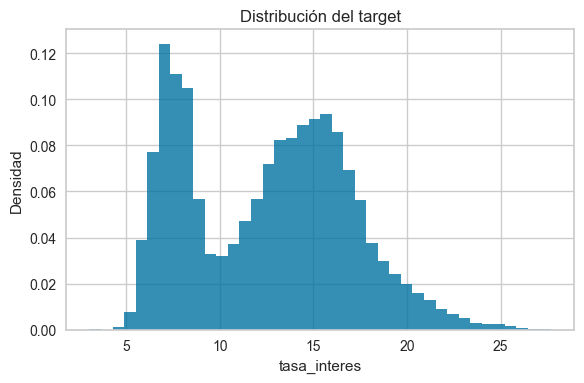

In [7]:

display(df_train.head(3))
display(df_train.describe(include='all').T.head(12))

print("\n% de nulos por columna (Top 10):")
print(df_train.isna().mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(6,4))
plt.hist(df_train['tasa_interes'], bins=40, density=True, alpha=0.8)
plt.xlabel('tasa_interes'); plt.ylabel('Densidad'); plt.title('Distribución del target')
plt.tight_layout(); plt.show()



<a id="pycaret"></a>

## 🤖 Automated Approach (PyCaret)

An automated modeling framework was implemented to accelerate experimentation and quickly identify high-performing algorithms.

This approach included:

Automated preprocessing (missing value imputation, encoding, normalization, and multicollinearity reduction)
Model comparison across multiple algorithms using RMSE as the primary metric
Hyperparameter tuning to improve model performance
Evaluation using cross-validation and hold-out validation

This allowed rapid iteration and efficient identification of strong baseline models.

In [8]:

# --- PyCaret (Regresión) ---
from pycaret.regression import setup, compare_models, tune_model, finalize_model, predict_model, pull, plot_model, save_model, load_model

reg_setup = setup(
    data=df_train,
    target='tasa_interes',
    train_size=0.85,
    fold=5,
    session_id=42,
    imputation_type='simple',
    categorical_imputation='most_frequent',
    numeric_imputation='median',
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
)

best_models = compare_models(n_select=3, sort='RMSE')
best = best_models[0] if isinstance(best_models, list) else best_models
tuned_best = tune_model(best, optimize='RMSE', n_iter=20, choose_better=True)

# Tabla de CV (folds)
cv_table = pull()
display(cv_table.tail())


,Description,Value
0,Session id,42
1,Target,tasa_interes
2,Target type,Regression
3,Original data shape,"(13923, 18)"
4,Transformed data shape,"(13923, 28)"
5,Transformed train set shape,"(11834, 28)"
6,Transformed test set shape,"(2089, 28)"
7,Ordinal features,1
8,Numeric features,13
9,Categorical features,4


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,1.0636,2.4103,1.5524,0.8732,0.0992,0.0801,0.3540
et,Extra Trees Regressor,1.2413,3.3338,1.8218,0.8243,0.1146,0.0920,0.7040
rf,Random Forest Regressor,1.3169,3.7650,1.9375,0.8016,0.1238,0.0988,1.8560
gbr,Gradient Boosting Regressor,1.4145,4.2959,2.0690,0.7736,0.1347,0.1087,1.4460
ada,AdaBoost Regressor,1.5763,4.9045,2.2138,0.7418,0.1469,0.1256,0.3400
omp,Orthogonal Matching Pursuit,1.7584,5.6567,2.3781,0.7024,0.1653,0.1443,0.0800
knn,K Neighbors Regressor,1.6902,5.8706,2.4228,0.6911,0.1571,0.1294,0.1680
llar,Lasso Least Angle Regression,2.0864,7.2857,2.6988,0.6167,0.1925,0.1790,0.0800
lasso,Lasso Regression,2.0864,7.2857,2.6988,0.6167,0.1925,0.1790,0.9800
en,Elastic Net,2.1766,7.5347,2.7446,0.6036,0.1998,0.1904,0.9040


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0847,2.5076,1.5835,0.8707,0.1016,0.0823
1,1.0863,2.4459,1.5639,0.8672,0.1013,0.0828
2,1.1058,2.5644,1.6014,0.8665,0.1040,0.0836
3,1.0832,2.4603,1.5685,0.8691,0.1001,0.0816
4,1.0666,2.4140,1.5537,0.8743,0.1004,0.0808
Mean,1.0853,2.4784,1.5742,0.8696,0.1015,0.0822
Std,0.0125,0.0525,0.0166,0.0028,0.0014,0.0010


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
2,1.1058,2.5644,1.6014,0.8665,0.1040,0.0836
3,1.0832,2.4603,1.5685,0.8691,0.1001,0.0816
4,1.0666,2.4140,1.5537,0.8743,0.1004,0.0808
Mean,1.0853,2.4784,1.5742,0.8696,0.1015,0.0822
Std,0.0125,0.0525,0.0166,0.0028,0.0014,0.0010



<a id="metrics-pycaret"></a>

## 🧪 Metrics & Visualisation (PyCaret)

Includes metrics, validation (CV y hold-out) and visulation graphics.


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1.0702,2.3922,1.5467,0.8735,0.0988,0.0805


Hold-out -> RMSE: 1.5467 | MAE: 1.0702 | R²: 0.8735


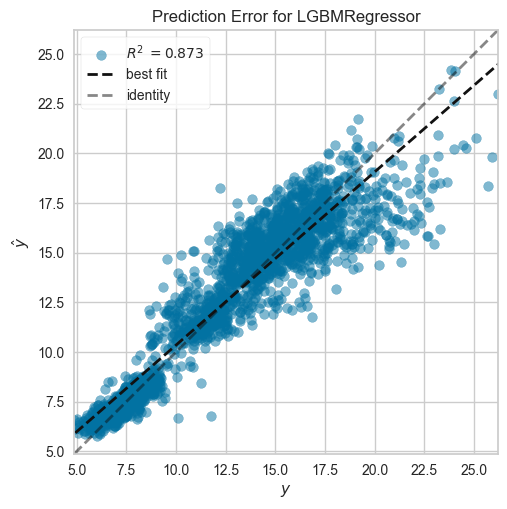

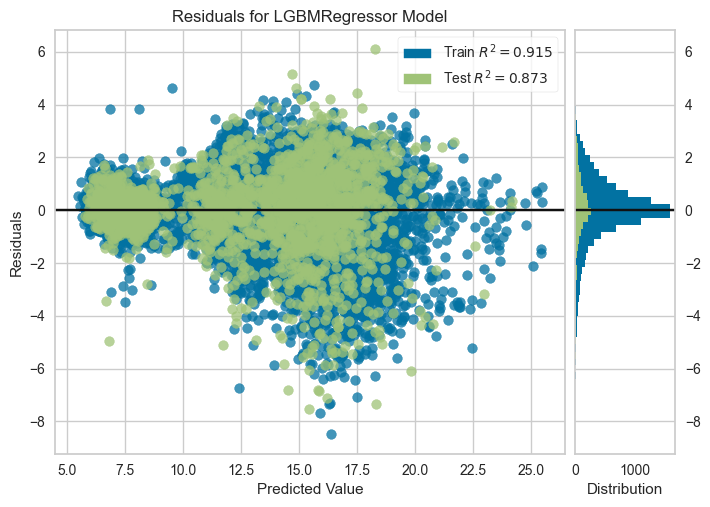

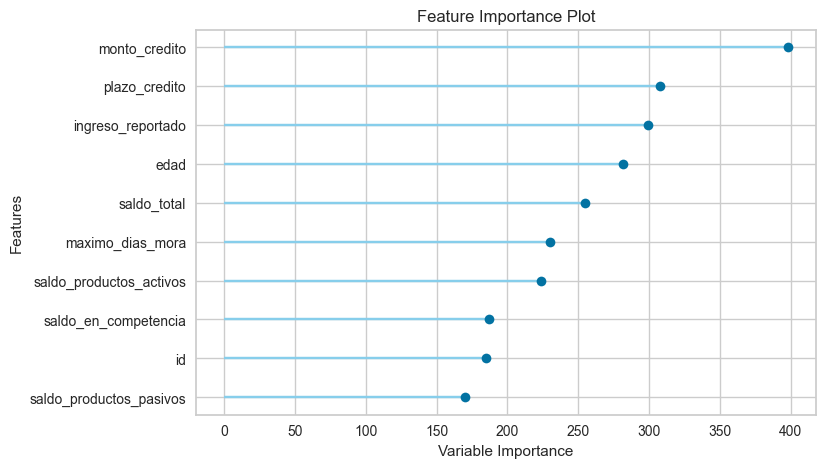

Archivo resultados.csv generado con 5967 filas
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['id', 'edad', 'ingreso_reportado',
                                              'maximo_dias_mora', 'saldo_total',
                                              'saldo_productos_activos',
                                              'saldo_productos_pasivos',
                                              'cantidad_productos_activos',
                                              'cantidad_productos_pasivos',
                                              'saldo_en_competencia',
                                              'monto_credito', 'plazo_credito',
                                              'calificacion_crediticia']...
                                     transformer=OneHotEncoder(cols=['categoria',
                                                                     'estado_civil',
                                                                    

In [9]:

# Hold-out con predict_model (sin data=)
pred_holdout = predict_model(tuned_best).copy()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = math.sqrt(mean_squared_error(pred_holdout['tasa_interes'], pred_holdout['prediction_label']))
mae  = mean_absolute_error(pred_holdout['tasa_interes'], pred_holdout['prediction_label'])
r2   = r2_score(pred_holdout['tasa_interes'], pred_holdout['prediction_label'])

print(f"Hold-out -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

# Gráficos PyCaret personalizables
plot_model(tuned_best, plot='error', plot_kwargs={'alpha':0.5, 'color':'royalblue', 's':25})
plot_model(tuned_best, plot='residuals', plot_kwargs={'alpha':0.5, 'color':'crimson', 's':25})
plot_model(tuned_best, plot='feature')

final_model = finalize_model(tuned_best)

pred_test = predict_model(final_model, data=df_test)


resultados = pd.DataFrame({
    "id": df_test["id"],
    "tasa_interes": pred_test["prediction_label"]
})
resultados.to_csv("resultados.csv", index=False)
print("Archivo resultados.csv generado con", len(resultados), "filas")
save_model(best, 'modelo_lightGBM_pycaret')


## 🧪 Model Diagnostics & Interpretation
Residual Analysis

The residual distribution shows that most prediction errors are centered around zero, indicating that the model does not present strong systematic bias.

With an R² of 0.916 (train) and 0.872 (test), the model demonstrates strong explanatory power while maintaining good generalization.

The relatively small gap between training and testing performance suggests that overfitting is minimal, and the model can be reliably applied to new data.

## 👉 Business implication:
The model can be trusted to produce stable interest rate estimations across different customer profiles, reducing the risk of inconsistent pricing.

Prediction Accuracy

The prediction error plot shows a strong alignment between actual and predicted values, with most observations following the identity line.

While some dispersion is observed in higher values, the overall performance remains strong (R² = 0.872).

## 👉 Business implication:
The model provides accurate estimates for most customers, though extreme cases may require additional validation or business rules.

Feature Importance

The model identifies monto_credito, plazo_credito, and saldo_total as the most influential variables in determining interest rates.

Less relevant variables (e.g., saldo_en_competencia, id) contribute minimally to predictions.

## 👉 Business implication:
Interest rate assignment is primarily driven by credit exposure and repayment structure, reinforcing the importance of these variables in risk-based pricing strategies.

## 🎯 Key Insight

The model confirms that financial exposure variables (amount, duration, and outstanding balance) are the primary drivers of interest rate determination.

This aligns with expected financial risk behavior and supports the use of data-driven pricing strategies.


<a id="sklearn"></a>

## 🛠️ Manual Approach (Scikit-learn + LightGBM)

A second approach was developed to maintain full control over the modeling pipeline and validate the robustness of results.

This included:

Explicit preprocessing using SimpleImputer and OneHotEncoder
Train-test split (80/20)
Model training using LightGBM within a Scikit-learn pipeline
Evaluation using standard regression metrics

This approach ensured transparency in each step of the process and allowed deeper understanding of model behavior.

In [10]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

num_cols = [
    'edad','ingreso_reportado','maximo_dias_mora','saldo_total',
    'saldo_productos_activos','saldo_productos_pasivos',
    'cantidad_productos_activos','cantidad_productos_pasivos',
    'saldo_en_competencia','monto_credito','plazo_credito',
    'calificacion_crediticia'
]
cat_cols = ['categoria','genero','estado_civil','garantia_credito']

def cap_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'plazo_credito' in df:            df['plazo_credito'] = np.clip(df['plazo_credito'], 30, 9000)
    if 'edad' in df:                      df['edad'] = np.clip(df['edad'], 16, 100)
    if 'calificacion_crediticia' in df:   df['calificacion_crediticia'] = np.clip(df['calificacion_crediticia'], 1, 10)
    return df

df_train = cap_df(df_train)
df_test  = cap_df(df_test)

TARGET = "tasa_interes"
ID_COL = "id"

X_train = df_train[num_cols + cat_cols]
y_train = df_train[TARGET]
X_test  = df_test[num_cols + cat_cols]


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

num_tf = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_tf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=True))
])

preprocess = ColumnTransformer([
    ('num', num_tf, num_cols),
    ('cat', cat_tf, cat_cols)
])

try:
    from lightgbm import LGBMRegressor
    model = LGBMRegressor(
        n_estimators=1200, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    model_name = "LightGBM"
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model = HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=600, random_state=42
    )
    model_name = "HistGradientBoosting"

pipe = Pipeline([('prep', preprocess), ('model', model)])


pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)


resultados = pd.DataFrame({ID_COL: df_test[ID_COL].values, 'tasa_interes': y_pred})
resultados['tasa_interes'] = resultados['tasa_interes'].astype(float).round(4)

print(f"Modelo: {model_name} | filas predichas: {len(resultados)}")
print(resultados.head(10))

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

pipe.fit(X_tr, y_tr)


y_val_pred = pipe.predict(X_val)


mae_rf  = mean_absolute_error(y_val, y_val_pred)
mse_rf  = mean_squared_error(y_val, y_val_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_val, y_val_pred)

print("Métricas en conjunto de validación:")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  MSE  : {mse_rf:.4f}")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

resultados_sk = pd.DataFrame({ID_COL: df_test[ID_COL].values, 'tasa_interes': y_pred})
resultados_sk['tasa_interes'] = resultados_sk['tasa_interes'].astype(float).round(4)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2266
[LightGBM] [Info] Number of data points in the train set: 13923, number of used features: 27
[LightGBM] [Info] Start training from score 12.558649
Modelo: LightGBM | filas predichas: 5967
       id  tasa_interes
0  865880       17.5071
1  697257        7.3618
2  246811        8.0760
3  272949       13.4191
4  913807       15.7631
5  794030       15.2090
6  582772       15.3026
7  557905        7.1396
8  964919       17.0290
9  845249        6.9535
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2249
[LightGBM] [Info] Number of data points in the train set: 11138, number of used features: 27
[LightGBM] [Info] Start training from score 12.539445
Métricas 


<a id="comparisson"></a>

## ⚖️ Metric comparisson

Metrics unified to check both models conclusions

In [11]:

# Consolidación de métricas
pycaret_row = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
sklearn_row = {'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf}

comparativa = pd.DataFrame({'PyCaret': pycaret_row, 'Scikit-learn': sklearn_row})
display(comparativa)

# Recomendación automática
winner = 'PyCaret' if (rmse < rmse_rf and r2 >= r2_rf) else 'Scikit-learn'
print(f"➡️ Recomendación: {winner} (basado en RMSE menor y R² mayor/igual)")


,PyCaret,Scikit-learn
RMSE,1.546664,1.565818
MAE,1.070247,1.066490
R2,0.873496,0.871216


➡️ Recomendación: PyCaret (basado en RMSE menor y R² mayor/igual)



<a id="graphics"></a>

## 🖼️ Presentation graphics

Graphics ready for informing: Real Scatter vs pred, residual and distributions.


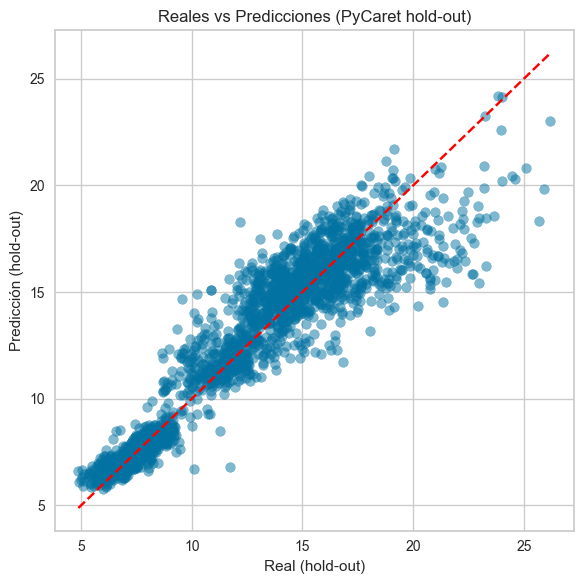

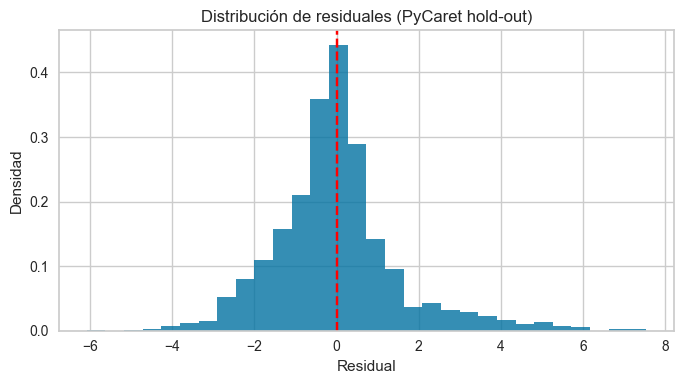

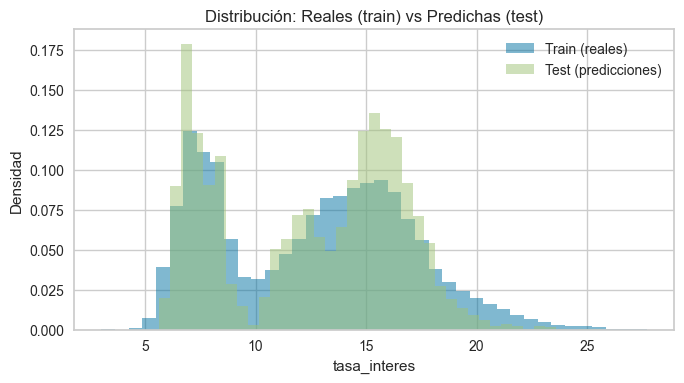

In [12]:

# Scatter: reales vs predicciones (hold-out PyCaret)
y_true = pred_holdout['tasa_interes']
y_pred = pred_holdout['prediction_label']

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
mn, mx = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], linestyle='--', color='red')
plt.xlabel('Real (hold-out)'); plt.ylabel('Predicción (hold-out)')
plt.title('Reales vs Predicciones (PyCaret hold-out)')
plt.tight_layout(); plt.show()

# Residuales
residuals = y_true - y_pred
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=30, density=True, alpha=0.8)
plt.axvline(0, linestyle='--', color='red')
plt.xlabel('Residual'); plt.ylabel('Densidad')
plt.title('Distribución de residuales (PyCaret hold-out)')
plt.tight_layout(); plt.show()

# Distribuciones: train reales vs test predichas
final_model = finalize_model(tuned_best)
pred_test = predict_model(final_model, data=df_test)

plt.figure(figsize=(7,4))
plt.hist(df_train['tasa_interes'].values, bins=40, density=True, alpha=0.5, label='Train (reales)')
plt.hist(pred_test['prediction_label'].values, bins=40, density=True, alpha=0.5, label='Test (predicciones)')
plt.xlabel('tasa_interes'); plt.ylabel('Densidad')
plt.title('Distribución: Reales (train) vs Predichas (test)')
plt.legend(); plt.tight_layout(); plt.show()


📈 Model Diagnostics
Real vs Predicted (Hold-out)

The scatter plot compares actual vs predicted interest rates on the validation dataset. The strong alignment along the identity line indicates that the model captures the underlying relationship effectively.

Some dispersion is observed at higher values, which is expected in more complex or extreme cases.

👉 Business implication:
The model provides reliable estimates for most customer profiles, with slightly higher uncertainty in extreme scenarios, where additional business rules could be applied.

## 4.Discusion

⚖️ Model Discussion

Both modeling approaches (PyCaret and Scikit-learn/LightGBM) delivered very similar performance in terms of accuracy and behavior.

This indicates that the primary difference lies not in predictive power, but in implementation strategy and operational context.

PyCaret enables rapid experimentation and fast delivery of results, making it ideal for prototyping and early-stage analysis.
Scikit-learn + LightGBM provides greater control, transparency, and flexibility, making it more suitable for production environments.

👉 Key insight:
Model selection should be driven by deployment needs and operational requirements, rather than marginal differences in performance.


<a id="conclusiones"></a>

## 📝 Conclusions & Recommendations

The results show that both approaches achieve strong and consistent performance (RMSE ~1.5–1.6, R² ~0.86–0.88), with no significant signs of overfitting.

The model demonstrates a strong ability to generalize and capture the relationship between financial variables and interest rate assignment.

## 🎯 Key Takeaways
The model is suitable for estimating interest rates in a consistent and scalable way.
Financial variables such as credit amount, loan duration, and outstanding balance are key drivers of pricing decisions.
Model predictions remain stable across validation sets, supporting reliability in real-world applications.
## 💼 Business Recommendations
Use the model to support risk-based pricing strategies, ensuring alignment between customer profile and assigned interest rate.
Combine model predictions with business rules for extreme cases, where higher uncertainty is observed.
Integrate the model into decision workflows to improve consistency and reduce manual adjustments.
## ⚙️ Technical Recommendations
Increase hyperparameter tuning iterations to further optimize performance.
Apply targeted feature engineering (ratios, interactions, segmentation).
Explore ensemble techniques such as blending or stacking.


<a id="exportables"></a>

## 📎 Exportables


In [13]:

# Guardar predicciones finales y comparativa
resultados = pd.DataFrame({
    'id': df_test['id'],
    'tasa_interes': pred_test['prediction_label']
})
assert len(resultados) == len(df_test) and resultados.isna().sum().sum() == 0
resultados.to_csv('resultados.csv', index=False)

comparativa.to_csv('comparativa_metricas.csv')
print('✅ Archivos generados: resultados.csv, comparativa_metricas.csv')


✅ Archivos generados: resultados.csv, comparativa_metricas.csv
